In [1]:
# Heart Disease Prediction with PyTorch Neural Network - Arihant Singh (3-5 Page Version)
# Biomedical Data Science Capstone Project
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, accuracy_score, f1_score, precision_score, recall_score)
import scipy.stats as stats
# Random seed as done in class for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [2]:
# Load the Cleveland Heart Disease Dataset
print("Loading Heart Dataset")
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
# read column names and print shape of the data, set null values to ?
df = pd.read_csv(url, names=column_names, na_values='?')
num_samples = df.shape[0]
num_features = df.shape[1]
print("We have", num_samples, "samples and", num_features, "features in the dataset")

Loading Heart Dataset
We have 303 samples and 14 features in the dataset


In [3]:
# Create a copy
heart_df = df.copy()
missing = heart_df.isnull()
missing_count = missing.sum()
# Drop missing values
heart_df = heart_df.dropna()
print("Heart dataset is of length after cleaning: ", str(len(heart_df)))
# Convert target to binary (0: no disease, 1: disease)
heart_df['target'] = (heart_df['target'] > 0).astype(int)

Heart dataset is of length after cleaning:  297


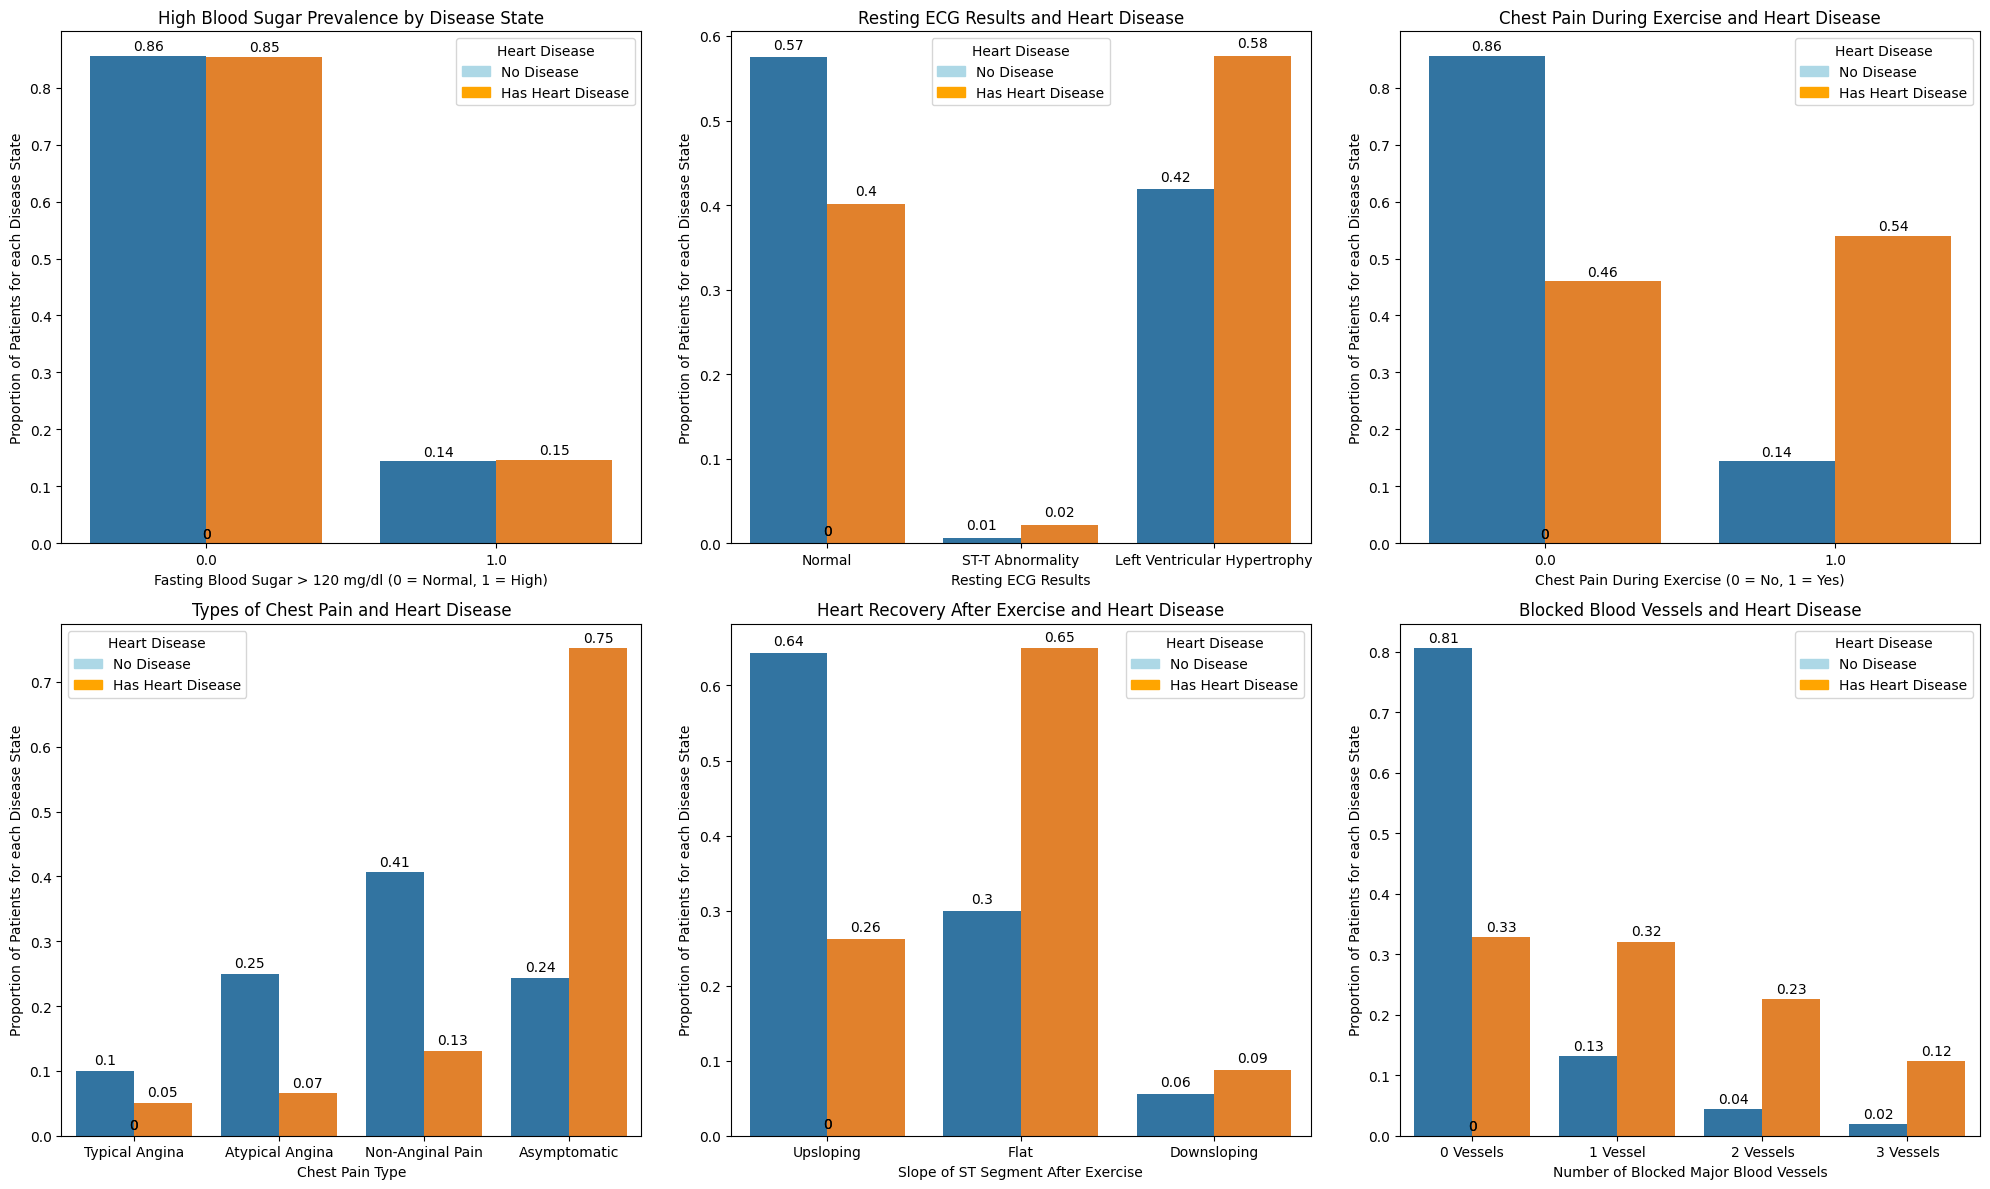

In [17]:
import matplotlib.patches as mpatches # setting color guide for custom figuress
import warnings
warnings.filterwarnings("ignore")
# count the number of people in each group to assign proportions
def count_people(df, col):
    # take a given column, i.e. a feature; and create sub-dfs containing only a given column and the single disease state
    counts = df.groupby([col, 'target']).size()
    # create a main_props dataframe with a counts column
    main_props = counts.reset_index(name='count')
    # proportions column initialized to 0
    main_props['prop'] = 0

    # for unique disease state labels (0 or 1)
    for t in main_props['target'].unique():
        # number of patients with the given disease state
        total = main_props[main_props['target'] == t]['count'].sum()
        # row indices corresponding to disease state
        indices = main_props[main_props['target'] == t].index
        for i in indices:
            # calculate proportion with the count divided by the total rows
            prop = main_props.loc[i, 'count'] / total
            main_props.loc[i, 'prop'] = prop
    return main_props

# showcase the features, title, x-axis with context, and categories if multi-class classification
# if binary, last column value is NA - no multi class classification occuring here
plot_data = [
    ('fbs', 'High Blood Sugar Prevalence by Disease State', 'Fasting Blood Sugar > 120 mg/dl (0 = Normal, 1 = High)', None),
    ('restecg', 'Resting ECG Results and Heart Disease', 'Resting ECG Results', ['Normal','ST-T Abnormality','Left Ventricular Hypertrophy']),
    ('exang', 'Chest Pain During Exercise and Heart Disease', 'Chest Pain During Exercise (0 = No, 1 = Yes)', None),
    ('cp', 'Types of Chest Pain and Heart Disease', 'Chest Pain Type', ['Typical Angina','Atypical Angina','Non-Anginal Pain','Asymptomatic']),
    ('slope', 'Heart Recovery After Exercise and Heart Disease', 'Slope of ST Segment After Exercise', ['Upsloping','Flat','Downsloping']),
    ('ca', 'Blocked Blood Vessels and Heart Disease', 'Number of Blocked Major Blood Vessels', ['0 Vessels','1 Vessel','2 Vessels','3 Vessels']),
    ('thal', 'Blood Flow to Heart and Heart Disease', 'Blood Flow Test Results', ['Normal Blood Flow','Fixed Defect','Reversible Defect'])
]

# create 2x3 subplot grid
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()  # flatten to 1D for easy indexing

# iterate through each element in the plot_data array
for idx, (col, title, xlabel, xticks_labels) in enumerate(plot_data[:6]):  # only first 6 to fit 2x3
    data = count_people(heart_df, col)
    # barplot showign proportions for the given x-axis and clinical context
    ax = sns.barplot(data=data, x=col, y='prop', hue="target", ax=axes[idx])

    # label placement above bar by height 0.01
    # patch.get_x() + patch.get_width()/2 keeps the label right in the middle of the given bar and the next bar
    # clustered columns
    for i, patch in enumerate(ax.patches):
        height = patch.get_height()
        ax.text(patch.get_x() + patch.get_width()/2, height + 0.01, round(height, 2),
                ha='center', fontsize=10)

    # title and labels
    axes[idx].set_title(title)
    axes[idx].set_xlabel(xlabel)
    axes[idx].set_ylabel('Proportion of Patients for each Disease State')
    # assign labels based on xtick values
    if xticks_labels:
        axes[idx].set_xticks(range(len(xticks_labels)))
        axes[idx].set_xticklabels(xticks_labels)

    # add legend with color coding
    blue_patch = mpatches.Patch(color='lightblue', label='No Disease')
    orange_patch = mpatches.Patch(color='orange', label='Has Heart Disease')
    axes[idx].legend(title='Heart Disease', handles=[blue_patch, orange_patch])

plt.tight_layout()
plt.show()

BUFFER SPACE FOR NEXT SECTION



In [5]:
# Neural Network Architecture inspired by literature, namely by Srivastava and Chatterjee (2025)
"""
Input layer with 13 features followed by batch normalization.
Next, a dense, hidden layer with 32 neurons, batch normalization, ReLU activation, and dropout.
Then a dense, hidden layer with 16 neurons, batch normalization, ReLU activation, and dropout.
Finally, a dense layer with 1 neuron, sigmoid activation, producing an output probability between 0 and 1.
"""
class HeartDiseaseNN(nn.Module):
    # Neural Network for Heart Disease Prediction inspired by "Achieving Superior Predictive Performance through Deep Neural Networks
    #for Enhanced Cardiovascular Disease Detection" (IJRPR 2025) by Srivastava and Chatterjee
    def __init__(self, input_size = 5, hidden_sizes=[32, 16], dropout_rate=0.4):
      super(HeartDiseaseNN, self).__init__()
      input_size = input_size # changing
      hidden1, hidden2 = hidden_sizes
      # dropout rate for regularization to prevent overfitting
      # tested 0.3 and found validation loss grew with time
      # also tested 128, 64, and 32 and found validation loss grw over time
      dropout_rate = 0.4
      # Input batch normalization, from literature
      self.input_bn = nn.BatchNorm1d(input_size)
      # two hidden layers; both followed by batch normalization and relu activation
      # dropout helps prevent overfitting
      # Relu and normalization from literature
      self.fc1 = nn.Linear(input_size, hidden1)
      self.bn1 = nn.BatchNorm1d(hidden1)
      self.act1 = nn.ReLU()
      self.drop1 = nn.Dropout(dropout_rate)
      self.fc2 = nn.Linear(hidden1, hidden2)
      self.bn2 = nn.BatchNorm1d(hidden2)
      self.act2 = nn.ReLU()
      self.drop2 = nn.Dropout(dropout_rate)
      # takes final 16 neurons and outputs a single neuron
      # sigmoid function used to predict probability of heart_disease_positive, between 0 and 1
      self.output = nn.Linear(hidden2, 1)
      self.output_activation = nn.Sigmoid()
    def forward(self, x):
      # Input normalization
      x = self.input_bn(x)
      # Process through hidden layers (2 of them)
      # Hidden layer 1
      x = self.fc1(x)
      x = self.bn1(x)
      x = self.act1(x)
      x = self.drop1(x)
      # Hidden layer 2
      x = self.fc2(x)
      x = self.bn2(x)
      x = self.act2(x)
      x = self.drop2(x)
      # Final output using sigmoid function
      # output is a probability that will be used to make decisions regarding disease status
      x = self.output(x)
      x = self.output_activation(x)
      return x

In [6]:
class HeartDataset(Dataset):
    def __init__(self, features, targets):
        # features and targets; flattened to 1 row for labels/targets
        self.features = torch.FloatTensor(features)
        self.targets = torch.FloatTensor(targets).unsqueeze(1)
    def __len__(self):
        return len(self.features)
    # return the features and target pair; proper pytorch dataset class referenced from: https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html
    def __getitem__(self, idx):
        return self.features[idx], self.targets[idx]

In [7]:
# X = all features except target, y = target column
X = heart_df.drop('target', axis=1)
y = heart_df['target']
# split X and y into train and test (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# scale features as done in previous homeworks
scaler = StandardScaler()
# fit scaler on train and transform it as well
X_train_scaled = scaler.fit_transform(X_train)
# use learned transform parameters to transform test
X_test_scaled = scaler.transform(X_test)
# new HeartDataset objects using scaled x and y paired data
train_dataset = HeartDataset(X_train_scaled, y_train.values)
test_dataset = HeartDataset(X_test_scaled, y_test.values)

In [8]:
# shuffle train but not test; batch the data as done prior; train loader the next step to loading tensors with PyTorch
batch_size = 20  # samples per batch; set to avoid having 1 sample per batch in last sample, and constrained by limited sample size
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
input_size = X_train_scaled.shape[1]  # number of features
# initialize model using input_size, or number of features
model = HeartDiseaseNN(input_size=input_size, hidden_sizes=[64, 32], dropout_rate=0.4)
# Loss and optimizer as done in class
criterion = nn.BCELoss()  # Binary Cross Entropy as shown before
# learning rate set to 0.001 from previous assignment
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
print("Input features:", input_size)
num_epochs = 30
train_losses = []
train_accuracies = []

for epoch in range(num_epochs):
    model.train()
    # zero loss and evaluation metrics at the beginning
    train_loss_epoch = 0
    train_correct = 0
    train_total = 0
    # for training_loader, reset gradients, move forward, and backpropagate
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        # compute BCE loss
        loss = criterion(outputs, batch_y)
        # backpropagate to compute new model weights
        loss.backward()
        optimizer.step()
        # sum loss
        train_loss_epoch += loss.item()
        # predictions (1 or 0)
        preds = []
        for o in outputs:
            # threshold set to 0.5
            if o > 0.5:
                preds.append(1.0)
            else:
                preds.append(0.0)
        # make preds a tensor
        preds = torch.tensor(preds)
        # count number of samples and number correct within that for training (likely higher than test)
        num_samples = 0
        for i in batch_y:
            num_samples += 1
        train_total += num_samples
        num_correct = 0
        for i in range(num_samples):
            if preds[i] == batch_y[i]:
                num_correct += 1
        train_correct += num_correct
    # calculate metrics for training
    train_loss = train_loss_epoch / len(train_loader)
    train_acc = 100 * train_correct / train_total
    # save metrics for plotting later
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    # print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print("Epoch", epoch+1, "of", num_epochs)
        print("Train Loss:", train_loss)
        print("Train Acc:", train_acc)


Input features: 13
Epoch 10 of 30
Train Loss: 0.44323790818452835
Train Acc: 80.59071729957806
Epoch 20 of 30
Train Loss: 0.411622978746891
Train Acc: 84.38818565400844
Epoch 30 of 30
Train Loss: 0.34449148550629616
Train Acc: 86.49789029535864


                  precision    recall  f1-score   support

No Heart Disease       0.82      0.88      0.85        32
         Disease       0.85      0.79      0.81        28

        accuracy                           0.83        60
       macro avg       0.83      0.83      0.83        60
    weighted avg       0.83      0.83      0.83        60



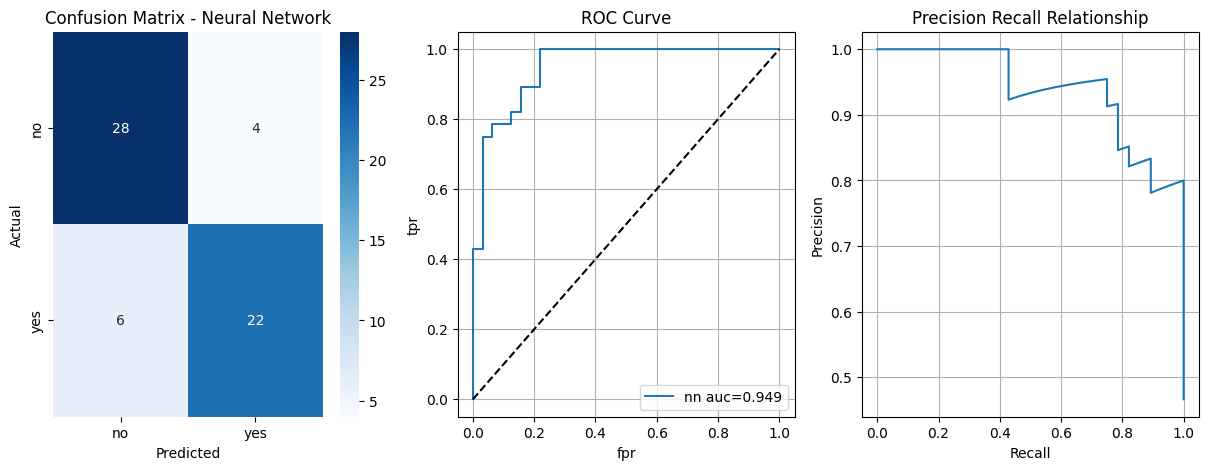

In [9]:
# setup test loader
batch_size = 20
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
# Model Evaluation
def evaluate_model(model, test_loader):
    # eval mode to prevent any kind of learning from going on
    model.eval()
    all_predictions = []
    all_probabilities = []
    all_targets = []
    # also pause gradient so no learning occurs
    with torch.no_grad():
        # load batch features and targets to predict on from model
        for batch_features, batch_targets in test_loader:
            # predict output probabilities and convert to numpy
            outputs = model(batch_features)
            probabilities = outputs.numpy()
            # render each output a binary 1 or 0
            predictions = (outputs > 0.5).float().numpy()
            # append to probabilities, predictions, and expectations or targets
            all_probabilities.extend(probabilities)
            all_predictions.extend(predictions)
            all_targets.extend(batch_targets.numpy())
    # return a series of arrays containing preds, probs, and targets
    return np.array(all_predictions), np.array(all_probabilities), np.array(all_targets)
# Get predictions
y_pred, y_proba, y_true = evaluate_model(model, test_loader)
# Compute accuracy, precision, recall, f1_score, and auc
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc_roc = roc_auc_score(y_true, y_proba)
# classification report gives details about classification accuracies, etc. with desired labels
print(classification_report(y_true, y_pred, target_names=['No Heart Disease', 'Disease']))
# Figures in one row; confusion matric, ROC curve, precision-recall curve
fig = plt.figure(figsize=(20, 5))
plt.subplot(1,4,1)
cm = confusion_matrix(y_true,y_pred)
# confusion matrix with annotations, blue colors used for labeling, xtick and ytick set to no or yes depending on presence
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['no','yes'],yticklabels=['no','yes'])
plt.title('Confusion Matrix - Neural Network')
plt.ylabel('Actual')
plt.xlabel('Predicted')
# ROC curve
plt.subplot(1,4,2)
# produce roc curve and fpr, tpr; plot the two against one another for roc curve
fpr,tpr,_ = roc_curve(y_true,y_proba)
plt.plot(fpr,tpr, label='nn auc=' + str(round(auc_roc,3)))
plt.plot([0,1],[0,1],'k--')
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
# Precision recall
plt.subplot(1,4,3)
prec,rec,_ = precision_recall_curve(y_true,y_proba)
plt.plot(rec,prec)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision Recall Relationship')
plt.grid(True)


Buffer Space for References

References

**Data Sourc**

UCI Heart Disease Dataset — UCI Repository

(Detrano, R. Am. J. Cardiol., 1989)

**Methodology**

Srivastava, Prof. (Dr.) N., & Chatterjee, P. (2025). Achieving Superior Predictive Performance through Deep Neural Networks for Enhanced Cardiovascular Disease Detection. International Journal of Research Publication and Reviews, 6(6), 5964–5968. https://doi.org/10.55248/gengpi.6.0625.21113


Paszke, A., Gross, S., Massa, F., Lerer, A., Bradbury, J., Chanan, G., Killeen, T., Lin, Z., Gimelshein, N., Antiga, L., Desmaison, A., Köpf, A., Yang, E., DeVito, Z., Raison, M., Tejani, A., Chilamkurthy, S., Steiner, B., Fang, L., & Bai, J. (2019). PyTorch: An Imperative Style, High-Performance Deep Learning Library. ArXiv.org. https://arxiv.org/abs/1912.01703

‌

**Libraries**

Matplotlib — Hunter, J. D. (2007). Computing in Science & Engineering, 9(3), 90–95. — Docs; Seaborn — Docs; Pandas — Docs